# FinanceAI - Exploratory Data Analysis

## Instrucciones

1. Ejecutar la primera celda.
2. Subir:
   - usuarios_sinteticos.csv
   - transacciones_sinteticas.csv
3. Ejecutar el resto del notebook en orden.

##1. Carga de datos

In [72]:
from google.colab import files
import pandas as pd

print("📂 Seleccioná los archivos:")
print("- usuarios_sinteticos.csv")
print("- transacciones_sinteticas.csv")

archivos = files.upload()

archivos_esperados = {
    "usuarios_sinteticos.csv",
    "transacciones_sinteticas.csv"
}

if not archivos_esperados.issubset(set(archivos.keys())):
    raise FileNotFoundError(
        "Debés subir usuarios_sinteticos.csv y transacciones_sinteticas.csv"
    )

usuarios = pd.read_csv("usuarios_sinteticos.csv")
transacciones = pd.read_csv("transacciones_sinteticas.csv")

print("✅ Archivos cargados correctamente.")

📂 Seleccioná los archivos:
- usuarios_sinteticos.csv
- transacciones_sinteticas.csv


Saving transacciones_sinteticas.csv to transacciones_sinteticas.csv
Saving usuarios_sinteticos.csv to usuarios_sinteticos.csv
✅ Archivos cargados correctamente.


In [73]:
import pandas as pd

usuarios = pd.read_csv("usuarios_sinteticos.csv")
transacciones = pd.read_csv("transacciones_sinteticas.csv")

##2. Librerias

In [74]:
import matplotlib.pyplot as plt

##3. Inspección básica

In [75]:
usuarios.head()

,usuario_id,ingreso_mensual,deuda_mensual,nivel_endeudamiento,gasto_mensual_promedio,ahorro_mensual_estimado,porcentaje_gastos_ingreso,frecuencia_ahorro,perfil_financiero
0,USR0001,4379.09,832.90,19.02,1114.31,2431.88,44.47,Alta,Saludable
1,USR0002,6100.14,968.09,15.87,1013.96,4118.09,32.49,Alta,Saludable
2,USR0003,4160.00,786.66,18.91,1708.73,1664.61,59.99,Alta,Saludable
3,USR0004,3609.86,1933.44,53.56,1306.01,370.41,89.74,Media,En riesgo
4,USR0005,1801.65,440.68,24.46,714.55,646.42,64.12,Alta,Saludable


In [76]:
transacciones.head()

,transaction_id,usuario_id,fecha,descripcion,monto,moneda,categoria,recurrente,medio_pago
0,TX001925,USR0042,2026-06-28,Servicio de limpieza,1792.13,USD,Vivienda,No,Pago con QR
1,TX000182,USR0056,2025-10-19,Cena,200.00,USD,Alimentación,No,Débito automático
2,TX002502,USR0095,2026-04-13,Parque recreativo,8.25,USD,Ocio,No,Pago con QR
3,TX001868,USR0027,2025-08-24,Compra de muebles,175.95,USD,Vivienda,Sí,Billetera virtual
4,TX002539,USR0071,2026-05-08,Suscripción de música,82.79,USD,Ocio,No,Pago con QR


In [77]:
usuarios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   usuario_id                 100 non-null    object 
 1   ingreso_mensual            100 non-null    float64
 2   deuda_mensual              100 non-null    float64
 3   nivel_endeudamiento        100 non-null    float64
 4   gasto_mensual_promedio     100 non-null    float64
 5   ahorro_mensual_estimado    100 non-null    float64
 6   porcentaje_gastos_ingreso  100 non-null    float64
 7   frecuencia_ahorro          100 non-null    object 
 8   perfil_financiero          100 non-null    object 
dtypes: float64(6), object(3)
memory usage: 7.2+ KB


In [78]:
transacciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  4500 non-null   object 
 1   usuario_id      4500 non-null   object 
 2   fecha           4500 non-null   object 
 3   descripcion     4500 non-null   object 
 4   monto           4500 non-null   float64
 5   moneda          4500 non-null   object 
 6   categoria       4500 non-null   object 
 7   recurrente      4500 non-null   object 
 8   medio_pago      4500 non-null   object 
dtypes: float64(1), object(8)
memory usage: 316.5+ KB


##4. Valores nulos y duplicados

In [79]:
usuarios.isnull().sum()

,0
usuario_id,0
ingreso_mensual,0
deuda_mensual,0
nivel_endeudamiento,0
gasto_mensual_promedio,0
ahorro_mensual_estimado,0
porcentaje_gastos_ingreso,0
frecuencia_ahorro,0
perfil_financiero,0


In [80]:
transacciones.isnull().sum()

,0
transaction_id,0
usuario_id,0
fecha,0
descripcion,0
monto,0
moneda,0
categoria,0
recurrente,0
medio_pago,0


In [81]:
usuarios.duplicated().sum()

np.int64(0)

In [82]:
transacciones.duplicated().sum()

np.int64(0)

##5. Estadísticas generales

In [83]:
usuarios.describe()

,ingreso_mensual,deuda_mensual,nivel_endeudamiento,gasto_mensual_promedio,ahorro_mensual_estimado,porcentaje_gastos_ingreso
count,100.0000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,4010.6611,1137.582300,28.584000,1311.911700,1570.251800,65.081000
std,1705.9868,797.723651,15.566561,396.713172,1212.466962,20.179167
min,1248.4900,12.240000,0.410000,561.340000,0.000000,25.550000
25%,2599.1025,482.342500,15.365000,980.580000,607.237500,48.185000
50%,3918.6100,941.800000,25.050000,1302.415000,1383.055000,65.930000
75%,5321.8350,1673.655000,41.990000,1592.315000,2124.580000,78.747500
max,6992.6900,3332.280000,54.260000,2370.990000,5126.970000,130.260000


In [84]:
transacciones.describe()

,monto
count,4500.000000
mean,349.843060
std,385.987433
min,1.120000
25%,103.737500
50%,211.380000
75%,439.515000
max,2000.000000


##6. Distribución de perfiles

In [85]:
usuarios["perfil_financiero"].value_counts()

,count
perfil_financiero,
Saludable,48
En observación,34
En riesgo,18


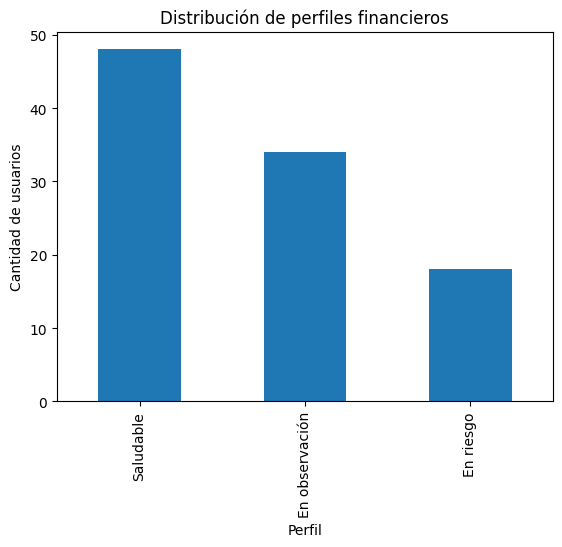

In [86]:
usuarios["perfil_financiero"].value_counts().plot(kind="bar")
plt.title("Distribución de perfiles financieros")
plt.xlabel("Perfil")
plt.ylabel("Cantidad de usuarios")
plt.show()

##7. Distribución por categoría

In [87]:
transacciones["categoria"].value_counts()

,count
categoria,
Vivienda,500
Alimentación,500
Ocio,500
Servicios,500
Otros,500
Transporte,500
Compras,500
Educación,500
Salud,500


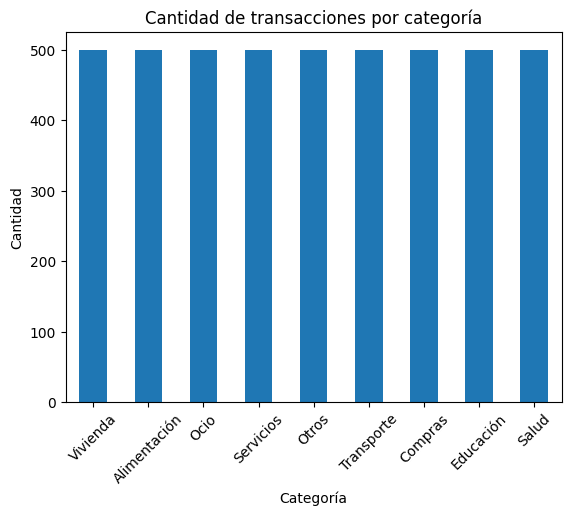

In [88]:
transacciones["categoria"].value_counts().plot(kind="bar")
plt.title("Cantidad de transacciones por categoría")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

##8. Gastos por categoría

In [89]:
gastos_categoria = (
    transacciones
    .groupby("categoria")["monto"]
    .sum()
    .sort_values(ascending=False)
)

gastos_categoria

,monto
categoria,
Vivienda,511885.34
Compras,262304.80
Educación,252289.27
Salud,130265.80
Otros,128989.91
Servicios,107920.93
Ocio,79227.85
Alimentación,54742.01
Transporte,46667.86


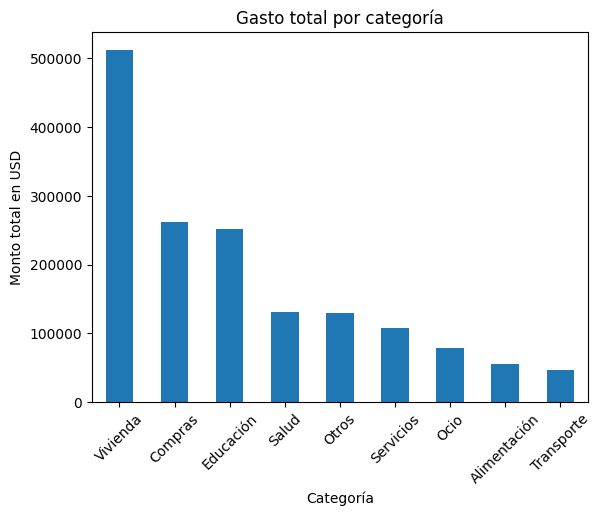

In [90]:
gastos_categoria.plot(kind="bar")
plt.title("Gasto total por categoría")
plt.xlabel("Categoría")
plt.ylabel("Monto total en USD")
plt.xticks(rotation=45)
plt.show()

##9. Medios de pago

In [91]:
transacciones["medio_pago"].value_counts()

,count
medio_pago,
Débito automático,658
Billetera virtual,648
Tarjeta de crédito,648
Pago con QR,644
Transferencia bancaria,644
Efectivo,640
Tarjeta de débito,618


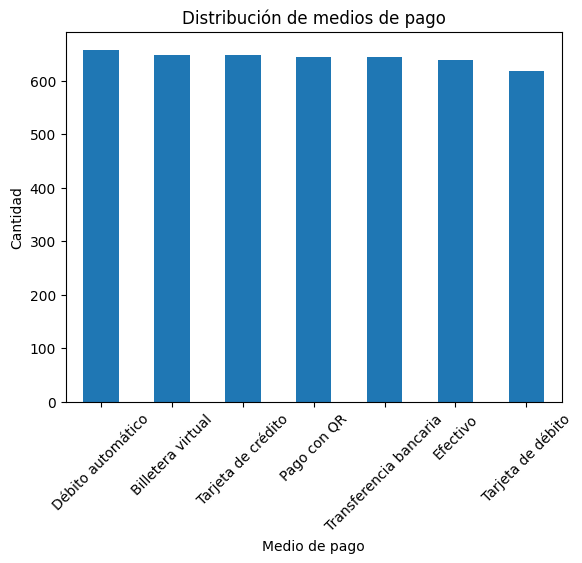

In [92]:
transacciones["medio_pago"].value_counts().plot(kind="bar")
plt.title("Distribución de medios de pago")
plt.xlabel("Medio de pago")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

##10. Relación entre ingresos, gastos y ahorro

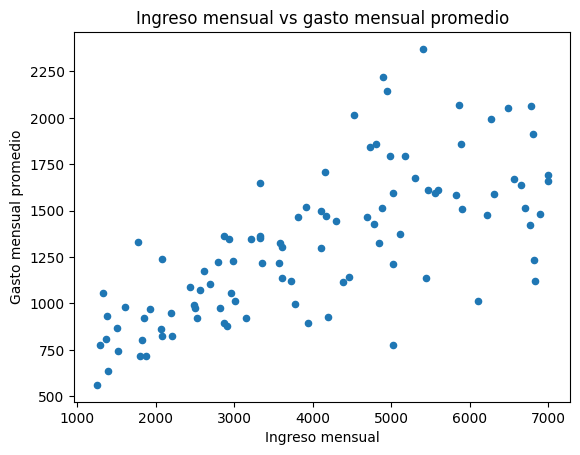

In [93]:
usuarios.plot(
    x="ingreso_mensual",
    y="gasto_mensual_promedio",
    kind="scatter"
)

plt.title("Ingreso mensual vs gasto mensual promedio")
plt.xlabel("Ingreso mensual")
plt.ylabel("Gasto mensual promedio")
plt.show()

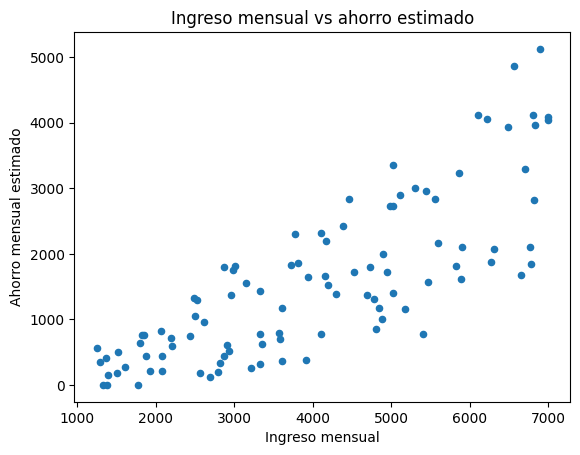

In [94]:
usuarios.plot(
    x="ingreso_mensual",
    y="ahorro_mensual_estimado",
    kind="scatter"
)

plt.title("Ingreso mensual vs ahorro estimado")
plt.xlabel("Ingreso mensual")
plt.ylabel("Ahorro mensual estimado")
plt.show()

##11. Unión de usuarios y transacciones

In [95]:
dataset_completo = transacciones.merge(
    usuarios,
    on="usuario_id",
    how="left"
)

dataset_completo.head()

,transaction_id,usuario_id,fecha,descripcion,monto,moneda,categoria,recurrente,medio_pago,ingreso_mensual,deuda_mensual,nivel_endeudamiento,gasto_mensual_promedio,ahorro_mensual_estimado,porcentaje_gastos_ingreso,frecuencia_ahorro,perfil_financiero
0,TX001925,USR0042,2026-06-28,Servicio de limpieza,1792.13,USD,Vivienda,No,Pago con QR,4099.27,286.13,6.98,1496.29,2316.85,43.48,Alta,Saludable
1,TX000182,USR0056,2025-10-19,Cena,200.00,USD,Alimentación,No,Débito automático,4099.78,2017.91,49.22,1298.82,783.05,80.90,Media,En riesgo
2,TX002502,USR0095,2026-04-13,Parque recreativo,8.25,USD,Ocio,No,Pago con QR,5862.32,563.96,9.62,2069.67,3228.69,44.92,Alta,Saludable
3,TX001868,USR0027,2025-08-24,Compra de muebles,175.95,USD,Vivienda,Sí,Billetera virtual,6274.40,2412.51,38.45,1992.61,1869.28,70.21,Alta,En observación
4,TX002539,USR0071,2026-05-08,Suscripción de música,82.79,USD,Ocio,No,Pago con QR,1879.20,726.12,38.64,718.42,434.66,76.87,Alta,En observación


##12. Distribución de ingresos

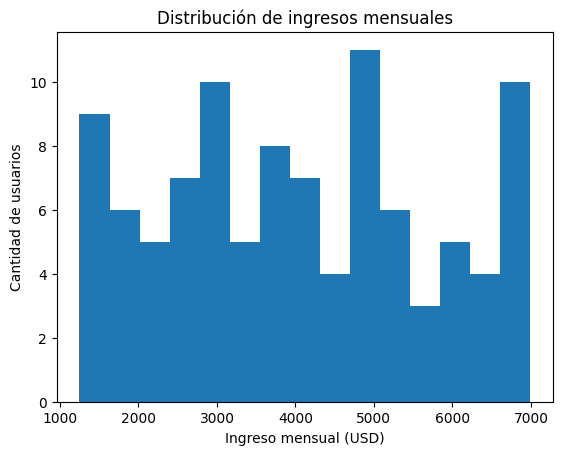

In [96]:
usuarios["ingreso_mensual"].plot(kind="hist", bins=15)
plt.title("Distribución de ingresos mensuales")
plt.xlabel("Ingreso mensual (USD)")
plt.ylabel("Cantidad de usuarios")
plt.show()

##13. Distribución del nivel de endeudamiento

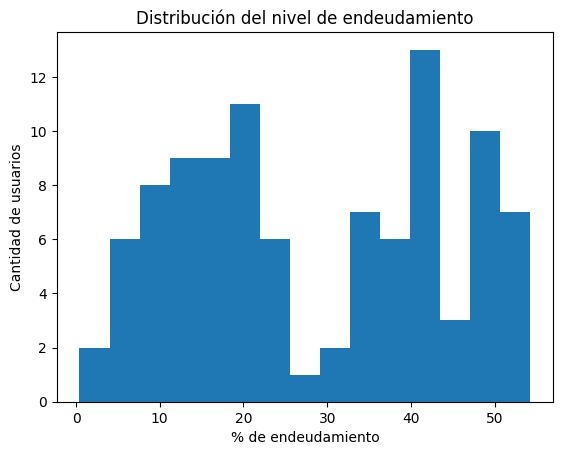

In [97]:
usuarios["nivel_endeudamiento"].plot(kind="hist", bins=15)
plt.title("Distribución del nivel de endeudamiento")
plt.xlabel("% de endeudamiento")
plt.ylabel("Cantidad de usuarios")
plt.show()

##14. Perfil financiero vs ahorro

In [98]:
usuarios.groupby("perfil_financiero")[
    "ahorro_mensual_estimado"
].mean()

,ahorro_mensual_estimado
perfil_financiero,
En observación,1290.635882
En riesgo,540.421111
Saludable,2154.499583


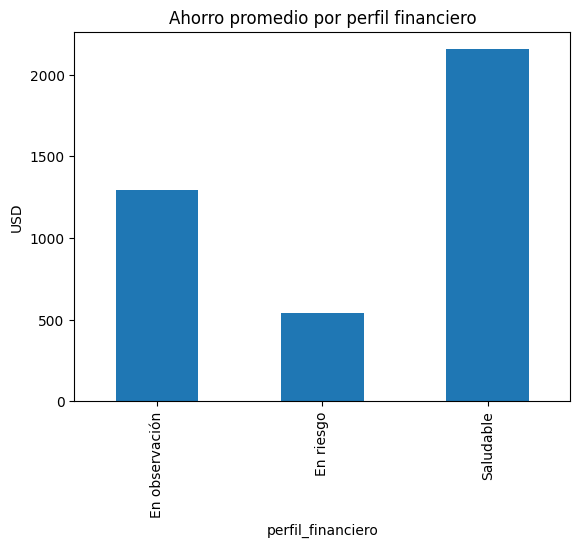

In [99]:
usuarios.groupby("perfil_financiero")[
    "ahorro_mensual_estimado"
].mean().plot(kind="bar")

plt.title("Ahorro promedio por perfil financiero")
plt.ylabel("USD")
plt.show()

##15. Top 10 descripciones

In [100]:
transacciones["descripcion"]\
    .value_counts()\
    .head(10)

,count
descripcion,
Mantenimiento del vehículo,68
Taxi,66
Transferencia personal,65
Certificación profesional,62
Almuerzo,61
Compra de ropa,61
Verdulería,60
Salida recreativa,58
Electricidad,58


##16. Gasto promedio por categoría

In [101]:
transacciones.groupby("categoria")["monto"]\
.mean()\
.sort_values(ascending=False)

,monto
categoria,
Vivienda,1023.77068
Compras,524.60960
Educación,504.57854
Salud,260.53160
Otros,257.97982
Servicios,215.84186
Ocio,158.45570
Alimentación,109.48402
Transporte,93.33572


##17. Correlación

In [102]:
usuarios[
[
"ingreso_mensual",
"deuda_mensual",
"gasto_mensual_promedio",
"ahorro_mensual_estimado",
"nivel_endeudamiento"
]
].corr()

,ingreso_mensual,deuda_mensual,gasto_mensual_promedio,ahorro_mensual_estimado,nivel_endeudamiento
ingreso_mensual,1.000000,0.550372,0.709923,0.801785,-0.033568
deuda_mensual,0.550372,1.000000,0.406862,-0.019936,0.749594
gasto_mensual_promedio,0.709923,0.406862,1.000000,0.401766,0.013824
ahorro_mensual_estimado,0.801785,-0.019936,0.401766,1.000000,-0.534225
nivel_endeudamiento,-0.033568,0.749594,0.013824,-0.534225,1.000000


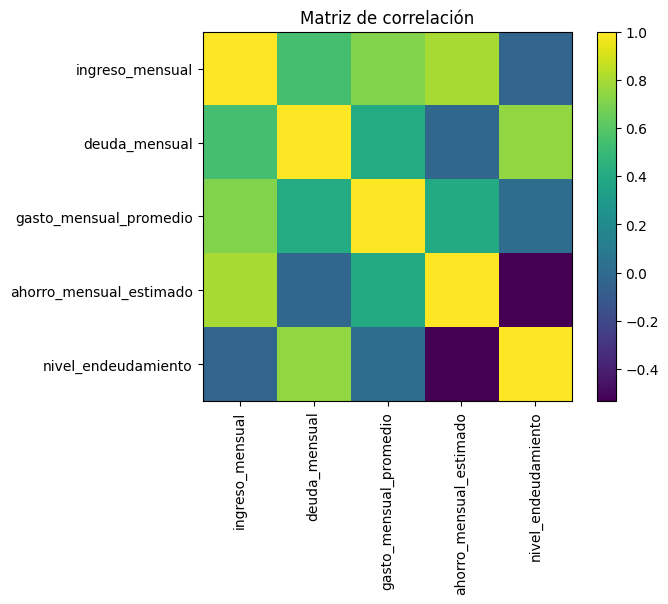

In [103]:
import matplotlib.pyplot as plt

corr = usuarios[
[
"ingreso_mensual",
"deuda_mensual",
"gasto_mensual_promedio",
"ahorro_mensual_estimado",
"nivel_endeudamiento"
]
].corr()

plt.imshow(corr)

plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)

plt.yticks(range(len(corr.columns)),corr.columns)

plt.colorbar()

plt.title("Matriz de correlación")

plt.show()

## Conclusiones iniciales

- El dataset está compuesto por 100 usuarios y 4500 transacciones.
- La distribución de transacciones por categoría es balanceada.
- Cada transacción se encuentra vinculada a un usuario mediante el campo `usuario_id`.
- Los usuarios cuentan con variables relacionadas con ingresos, deuda, gastos, ahorro y perfil financiero.
- La estructura de los datos permite abordar tanto la clasificación de transacciones como el análisis del perfil financiero de los usuarios.
- No se detectaron valores nulos ni registros duplicados.
- En las siguientes etapas se realizará el preprocesamiento de los datos, la ingeniería de atributos y el entrenamiento de modelos para la clasificación de transacciones y la evaluación del perfil financiero.
- Los datos utilizados fueron generados mediante un generador sintético desarrollado específicamente para el proyecto FinanceAI.

## Próximos pasos

- Preprocesamiento de variables.
- Ingeniería de atributos.
- Entrenamiento del modelo de clasificación de transacciones.
- Evaluación del perfil financiero.
- Integración del modelo con la API REST.